In [1]:
import os
import pathlib
import kagglehub
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50, resnet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization, Input
from tensorflow.keras.optimizers.schedules import ExponentialDecay
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.losses import CategoricalCrossentropy
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import cv2

2026-06-10 05:17:28.414366: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781068648.623422      22 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781068648.683915      22 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781068649.225693      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781068649.225741      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781068649.225744      22 computation_placer.cc:177] computation placer alr

In [2]:
# Download latest version
path = kagglehub.dataset_download("mohamedhanyyy/chest-ctscan-images")

print("Path to dataset files:", path)

# Define the dataset path based on the downloaded location
dataset_path = path

# Convert to pathlib object for easier navigation
data_dir = pathlib.Path(dataset_path)

# Retrieve all image paths (assuming common image formats like jpg, png)
# The recursive glob '**/*' finds files in all subdirectories
all_image_paths = list(data_dir.glob('**/*.jpg')) + list(data_dir.glob('**/*.png'))

# Count the total number of images found
image_count = len(all_image_paths)

# List the main subdirectories (usually the classes or splits)
categories = [item.name for item in data_dir.iterdir() if item.is_dir()]

# Print basic information about the loaded data
print(f"Dataset path: {dataset_path}")
print(f"Total images found: {image_count}")
print(f"Categories/Folders found: {categories}")

# Print the first 5 image paths as a sample
print("\nSample image paths:")
for p in all_image_paths[:5]: # Renamed 'path' to 'p' to avoid conflict with variable 'path'
    print(p)

Path to dataset files: /kaggle/input/datasets/mohamedhanyyy/chest-ctscan-images
Dataset path: /kaggle/input/datasets/mohamedhanyyy/chest-ctscan-images
Total images found: 1000
Categories/Folders found: ['Data']

Sample image paths:
/kaggle/input/datasets/mohamedhanyyy/chest-ctscan-images/Data/train/normal/n6 - Copy.jpg
/kaggle/input/datasets/mohamedhanyyy/chest-ctscan-images/Data/train/normal/n9 - Copy.jpg
/kaggle/input/datasets/mohamedhanyyy/chest-ctscan-images/Data/train/normal/n6 (2) - Copy.jpg
/kaggle/input/datasets/mohamedhanyyy/chest-ctscan-images/Data/train/normal/n8 (2).jpg
/kaggle/input/datasets/mohamedhanyyy/chest-ctscan-images/Data/train/normal/n8.jpg


In [3]:
# Enable mixed precision for faster training
tf.keras.mixed_precision.set_global_policy('mixed_float16')

In [4]:
# Define dataset paths based on downloaded location
base_dir = os.path.join(dataset_path, "Data")

train_path = os.path.join(base_dir, "train")
valid_path = os.path.join(base_dir, "valid")
test_path  = os.path.join(base_dir, "test")

BATCH_SIZE = 32
IMG_SHAPE = (460, 460)

print(train_path)
print(valid_path)
print(test_path)

/kaggle/input/datasets/mohamedhanyyy/chest-ctscan-images/Data/train
/kaggle/input/datasets/mohamedhanyyy/chest-ctscan-images/Data/valid
/kaggle/input/datasets/mohamedhanyyy/chest-ctscan-images/Data/test


In [5]:
train_datagen = ImageDataGenerator(
    preprocessing_function=resnet50.preprocess_input,
    rotation_range=25,
    horizontal_flip=True,
    zoom_range=0.25,
    shear_range=0.2,
    brightness_range=[0.75,1.25],
    width_shift_range=0.1,
    height_shift_range=0.1,
    fill_mode='nearest'
)

valid_datagen = ImageDataGenerator(
    preprocessing_function=resnet50.preprocess_input
)

test_datagen = ImageDataGenerator(
    preprocessing_function=resnet50.preprocess_input
)

In [6]:
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SHAPE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

valid_generator = valid_datagen.flow_from_directory(
    valid_path,
    target_size=IMG_SHAPE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=IMG_SHAPE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

class_names = list(train_generator.class_indices.keys())
print("Classes:", class_names)

Found 613 images belonging to 4 classes.
Found 72 images belonging to 4 classes.
Found 315 images belonging to 4 classes.
Classes: ['adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib', 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa', 'normal', 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa']


In [7]:


# Extract class indices from the generator
classes = train_generator.classes

# Compute weights to handle class imbalance
# np.unique finds the unique class labels
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(classes),
    y=classes
)

# Convert weights to a dictionary format required by Keras/TensorFlow
class_weights = dict(enumerate(class_weights))

print("Class Weights:", class_weights)

Class Weights: {0: np.float64(0.7858974358974359), 1: np.float64(1.3326086956521739), 2: np.float64(1.035472972972973), 3: np.float64(0.9887096774193549)}


In [8]:
input_tensor = Input(shape=(460, 460, 3))
base_model = ResNet50(include_top=False, weights='imagenet', input_tensor=input_tensor)

# Unfreeze last blocks
for layer in base_model.layers:
    if not ('conv5' in layer.name or 'conv4' in layer.name):
        layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)

x = Dense(128, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

output = Dense(4, activation='softmax', dtype='float32')(x)

model = Model(inputs=base_model.input, outputs=output)

I0000 00:00:1781068666.355747      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [9]:
# Use a float instead of a schedule
initial_lr = 3e-5

loss_fn = CategoricalCrossentropy(label_smoothing=0.1)

# Pass the float directly
optimizer = Adam(learning_rate=initial_lr)

model.compile(
    optimizer=optimizer,
    loss=loss_fn,
    metrics=['accuracy']
)

# Now you can safely use callbacks
checkpoint = ModelCheckpoint(
    "chest_resnet50_best.keras",
    save_best_only=True,
    monitor='val_loss',
    verbose=1
)

earlystop = EarlyStopping(
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# Optional: You can now add this since LR is a float
# reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5)

In [10]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

# Define the missing callback
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,   # Multiply LR by 0.2 when triggered
    patience=3,    # Wait 3 epochs before dropping
    min_lr=1e-7,   # Don't let it go below this
    verbose=1
)

# Now run your fit
history = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=25,
    class_weight=class_weights,
    callbacks=[checkpoint, earlystop, reduce_lr]
)

Epoch 1/25


I0000 00:00:1781068703.477086      87 service.cc:152] XLA service 0x7c15040025c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781068703.477127      87 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1781068708.771872      87 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1781068739.120108      87 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.2854 - loss: 1.8167
Epoch 1: val_loss improved from None to 1.26823, saving model to chest_resnet50_best.keras

Epoch 1: finished saving model to chest_resnet50_best.keras
20/20 ━━━━━━━━━━━━━━━━━━━━ 131s 4s/step - accuracy: 0.3230 - loss: 1.7245 - val_accuracy: 0.3750 - val_loss: 1.2682 - learning_rate: 3.0000e-05
Epoch 2/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4546 - loss: 1.3810
Epoch 2: val_loss improved from 1.26823 to 1.15524, saving model to chest_resnet50_best.keras

Epoch 2: finished saving model to chest_resnet50_best.keras
20/20 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step - accuracy: 0.4845 - loss: 1.3311 - val_accuracy: 0.5000 - val_loss: 1.1552 - learning_rate: 3.0000e-05
Epoch 3/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4957 - loss: 1.3689
Epoch 3: val_loss improved from 1.15524 to 1.08913, saving model to chest_resnet50_best.keras

Epoch 3: finished saving model to chest_resnet50_best.keras
20/20 ━━━━━━━

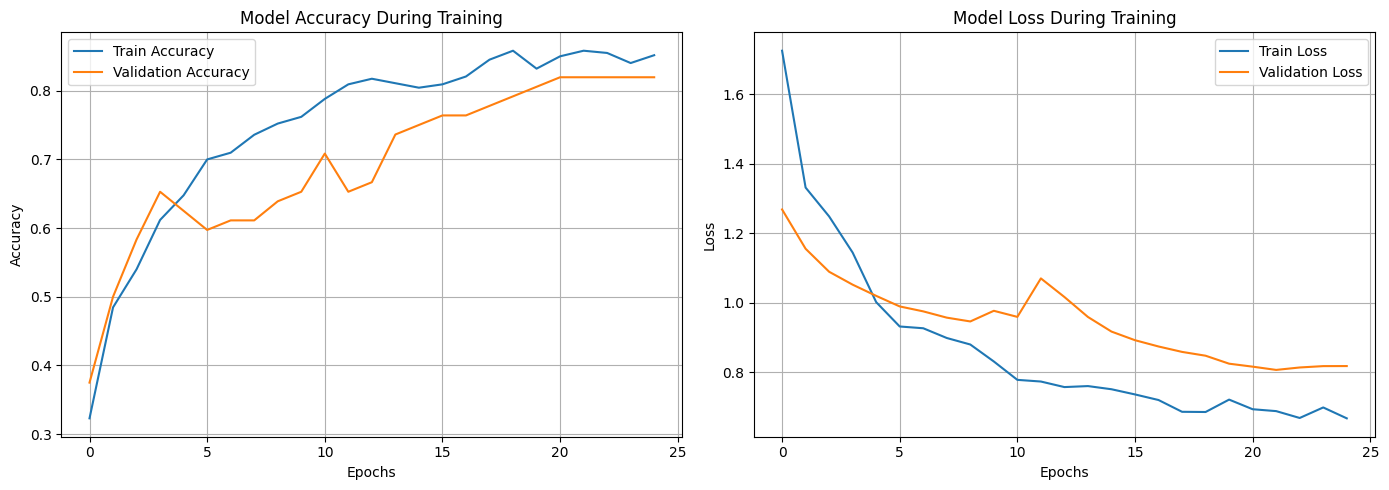

In [11]:

# ===== Training History Visualization =====

plt.figure(figsize=(14,5))

# Accuracy Curve
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy During Training')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss Curve
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss During Training')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [12]:
# Save full model after training
model.save("final_lung_cancer_type_model.h5")

print("Model saved successfully")


Model saved successfully


10/10 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step
Classification Report:

                                                  precision    recall  f1-score   support

      adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib       0.88      0.68      0.76       120
   large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa       0.71      0.94      0.81        51
                                          normal       0.90      0.98      0.94        54
squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa       0.80      0.86      0.83        90

                                        accuracy                           0.82       315
                                       macro avg       0.82      0.86      0.83       315
                                    weighted avg       0.83      0.82      0.82       315



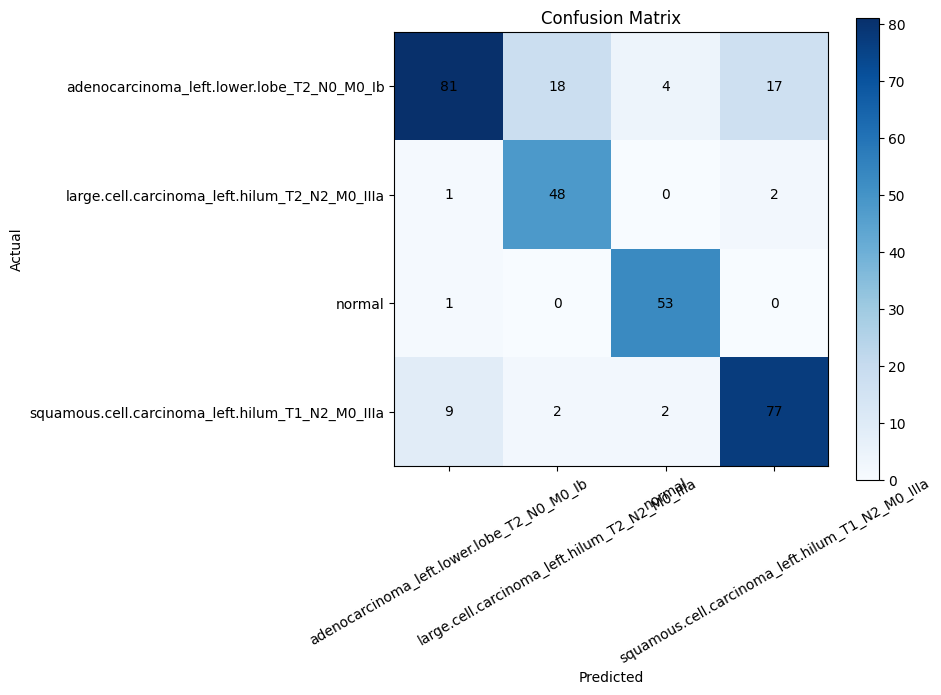

In [13]:
# Predictions
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes

# Classification Report
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7,6))
plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix")
plt.colorbar()

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.xticks(range(len(class_names)), class_names, rotation=30)
plt.yticks(range(len(class_names)), class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
Using convolution layer: conv5_block3_out


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 460, 460, 3))
  warnings.warn(msg)


True Class     : adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib
Predicted Class: adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib


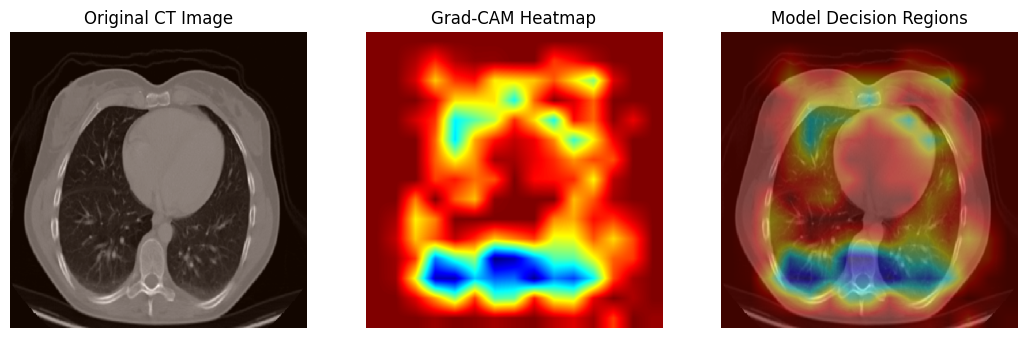

In [14]:
# ===== COMPLETE GRAD-CAM PIPELINE (Standalone Cell) =====





# 1) Take one batch from test generator
sample_batch = next(iter(test_generator))
sample_imgs, sample_labels = sample_batch

# 2) Select first image from batch
img = sample_imgs[0]
true_class = np.argmax(sample_labels[0])

# 3) Prepare image for model
input_img = np.expand_dims(img, axis=0)

# 4) Prediction
preds = model.predict(input_img)
pred_class = np.argmax(preds[0])

# 5) Automatically detect last conv layer
last_conv_layer = None
for layer in reversed(model.layers):
    if 'conv' in layer.name:
        last_conv_layer = layer.name
        break

print("Using convolution layer:", last_conv_layer)

# 6) Grad-CAM Function
def get_gradcam(model, img_array, class_index, layer_name):

    grad_model = Model(
        inputs=model.inputs,
        outputs=[model.get_layer(layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, class_index]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Ensure heatmap contains only finite values before further processing
    heatmap = tf.where(tf.math.is_nan(heatmap), 0.0, heatmap)
    heatmap = tf.where(tf.math.is_inf(heatmap), 0.0, heatmap)

    # Handle potential division by zero if all positive gradients are zero
    max_val = tf.math.reduce_max(heatmap)
    if max_val == 0:
        # If the max value is 0, the heatmap would be all zeros anyway
        # but to avoid division by zero, we return a zero heatmap
        normalized_heatmap = tf.zeros_like(heatmap, dtype=tf.float32)
    else:
        normalized_heatmap = tf.maximum(heatmap, 0) / max_val

    # Convert to numpy and explicitly ensure float32 and contiguity for OpenCV compatibility
    heatmap_np = normalized_heatmap.numpy()
    heatmap_np = np.ascontiguousarray(heatmap_np, dtype=np.float32)

    return heatmap_np

# 7) Generate heatmap
heatmap = get_gradcam(model, input_img, pred_class, last_conv_layer)

heatmap = cv2.resize(heatmap, (IMG_SHAPE[0], IMG_SHAPE[1]))
heatmap = np.uint8(255 * heatmap)
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

# 8) Prepare original image for display
orig = img.copy()
orig = orig - orig.min()
orig = orig / orig.max()
orig = np.uint8(255 * orig)

superimposed = cv2.addWeighted(orig, 0.6, heatmap, 0.4, 0)

# 9) Visualization
plt.figure(figsize=(13,5))

plt.subplot(1,3,1)
plt.imshow(orig)
plt.title("Original CT Image")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(heatmap)
plt.title("Grad-CAM Heatmap")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(superimposed)
plt.title("Model Decision Regions")
plt.axis('off')

print("True Class     :", class_names[true_class])
print("Predicted Class:", class_names[pred_class])